# PREVISIONE POPOLARITÀ CANZONI
Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26  
Realizzato da Ciro Bassi (ciro.bassi@studio.unibo.it) e Alessandro Testa (alessandro.testa9@studio.unibo.it)

## 1. Introduzione e Contesto

### 1.1 Obiettivi del progetto

L'obiettivo del progetto è sviluppare un modello in grado di predire la popolarità di un brano musicale su Spotify a partire dalle sue caratteristiche audio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### 1.2 Dataset utilizzato
Il dataset utilizzato è il [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset), disponibile su Kaggle. Contiene circa 114.000 brani Spotify appartenenti a 114 generi musicali diversi, con le seguenti informazioni:

**Metadati:**
- `track_id`: identificatore univoco del brano su Spotify
- `artists`: nomi degli artisti, separati da `;` in caso di collaborazioni
- `album_name`: nome dell'album
- `track_name`: titolo del brano
- `duration_ms`: durata del brano in millisecondi
- `explicit`: indica se il brano contiene contenuto esplicito (1 = sì, 0 = no)
- `track_genre`: genere musicale del brano
- `popularity`: score tra 0 e 100 calcolato da Spotify in base al numero di ascolti recenti. Brani molto ascoltati di recente hanno score più alto rispetto a brani popolari in passato.

**Feature audio**:
- `danceability` (0–1): idoneità del brano al ballo, basata su tempo, ritmo e regolarità
- `energy` (0–1): intensità e attività percettiva; brani energetici sono veloci, forti e rumorosi
- `loudness` (dB): volume medio del brano
- `speechiness` (0–1): presenza di parlato; valori sopra 0.66 indicano brani prevalentemente parlati
- `acousticness` (0–1): probabilità che il brano sia acustico
- `instrumentalness` (0–1): probabilità che il brano non contenga voci
- `liveness` (0–1): presenza di pubblico nella registrazione; sopra 0.8 indica alta probabilità di live
- `valence` (0–1): positività emotiva trasmessa dal brano; valori alti = felice/euforico, bassi = triste/malinconico
- `tempo` (BPM): velocità stimata in battiti per minuto
- `key` (0–11): tonalità del brano (0 = Do, 1 = Do#, ecc.)
- `mode` (0/1): modalità della scala — 1 = maggiore, 0 = minore
- `time_signature` (3–7): numero di battiti per misura

`popularity`sarà la variabile target da predire.

In [2]:
import os.path
file = "dataset.csv";
if not os.path.exists(file):
    print("Missing dataset");

df = pd.read_csv(file, index_col=0);

df.info(verbose=False, memory_usage="deep");
df.head(1)

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), float64(9), int64(5), str(5)
memory usage: 48.8 MB


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


### 1.4 Pulizia iniziale dei dati
Prima di procedere con l’analisi dei dati, si effettua una prima fase di scrematura.

#### Rimozione colonne non informative

`track_id`: identificatore univoco di un brano, rimosso poichè non utile all'analisi.

In [3]:
df.drop(columns=["track_id"], inplace=True)

#### Valori nulli
Rimozione di eventuali righe con valori nulli.

In [4]:

df.isnull().sum()
df = df.dropna()

Rimozione dei brani con `popularity` = 0.

In [5]:
df = df[df['popularity'] != 0]

Una frazione consistente dei brani del dataset ha `popularity` = 0. Se non rimosse rischiano di distorce la regressione.

#### Duplicati
Il dataset contiene molte righe con stesso `track_name` + `artists` (stesso brano in più album). 
Questo è un problema, poichè inquinano il test set e distorcono l'analisi dei dati.

Conviene quindi aaggregare dei brani con stesso nome e artisti, mantenendo solo la versione con `popularity` massima.

In [6]:
df = df.sort_values('popularity', ascending=False).drop_duplicates(subset=['track_name', 'artists'])

### 1.5 Conversioni e derivazioni
Conversione dei millisecondi in secondi.

In [7]:
df['duration_s'] = df['duration_ms'] / 1000
df = df.drop(columns=['duration_ms'])

Creazione della colonna `num_artists` (numero di artisti per ogni brano).

In [8]:
df['num_artists'] = df['artists'].astype(str).str.split(';').str.len()
df.head(1)

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s,num_artists
20001,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,False,0.714,0.472,2,-7.375,1,0.0864,0.013,0.000005,0.266,0.238,131.121,4,dance,156.943,2


#### Conversione delle stringhe in categorie

Le colonne testuali ad alta cardinalità (`track_genre`, `artists`, `album_name`) vengono convertite al dtype `category`.

In [9]:
for col in ['track_genre', 'artists', 'album_name']:
    df[col] = df[col].astype('category')

Con questa prima scrematura, la dimensione del dataset è stata ridotta significativamente.

In [10]:
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 76585 entries, 20001 to 60590
Columns: 20 entries, artists to num_artists
dtypes: bool(1), category(3), float64(10), int64(5), str(1)
memory usage: 20.7 MB


## 2. Analisi dei dati

### 2.1 Statistiche descrittive generali

In [11]:
print('tracks: \t' + str(len(df)))
print('artists:\t' + str(df['artists'].nunique()))
print('albums: \t' + str(df.groupby(['album_name', 'artists'], observed=True).ngroups))
print('genres: \t' + str(df['track_genre'].nunique()))

df.describe()

tracks: 	76585
artists:	29826
albums: 	53196
genres: 	114


,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_s,num_artists
count,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000
mean,37.439303,0.561695,0.640234,5.287263,-8.496698,0.633349,0.089653,0.322805,0.183126,0.221368,0.465632,122.416330,3.900268,231.499167,1.368036
std,17.837212,0.176131,0.255269,3.558216,5.187510,0.481893,0.118414,0.335335,0.330334,0.200116,0.262399,30.075551,0.450232,116.630574,0.881734
min,1.000000,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.266000,1.000000
25%,23.000000,0.450000,0.464000,2.000000,-10.327000,0.000000,0.036000,0.015000,0.000000,0.098700,0.246000,99.915000,4.000000,173.973000,1.000000
50%,37.000000,0.575000,0.682000,5.000000,-7.232000,1.000000,0.049200,0.184000,0.000085,0.133000,0.451000,122.369000,4.000000,215.689000,1.000000
75%,50.000000,0.691000,0.859000,8.000000,-5.130000,1.000000,0.087600,0.614000,0.144000,0.285000,0.677000,140.655000,4.000000,267.847000,1.000000
max,100.000000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,5237.295000,38.000000


Il dataset contiene quindi informazioni relative a 76585 brani, 29826 artisti, 53199 album e 114 generi.

### 2.2 Distribuzione delle feature
Di seguito vengono visualizzati alcuni istogrammi e statistiche per analizzare la distribuzione dei dati.

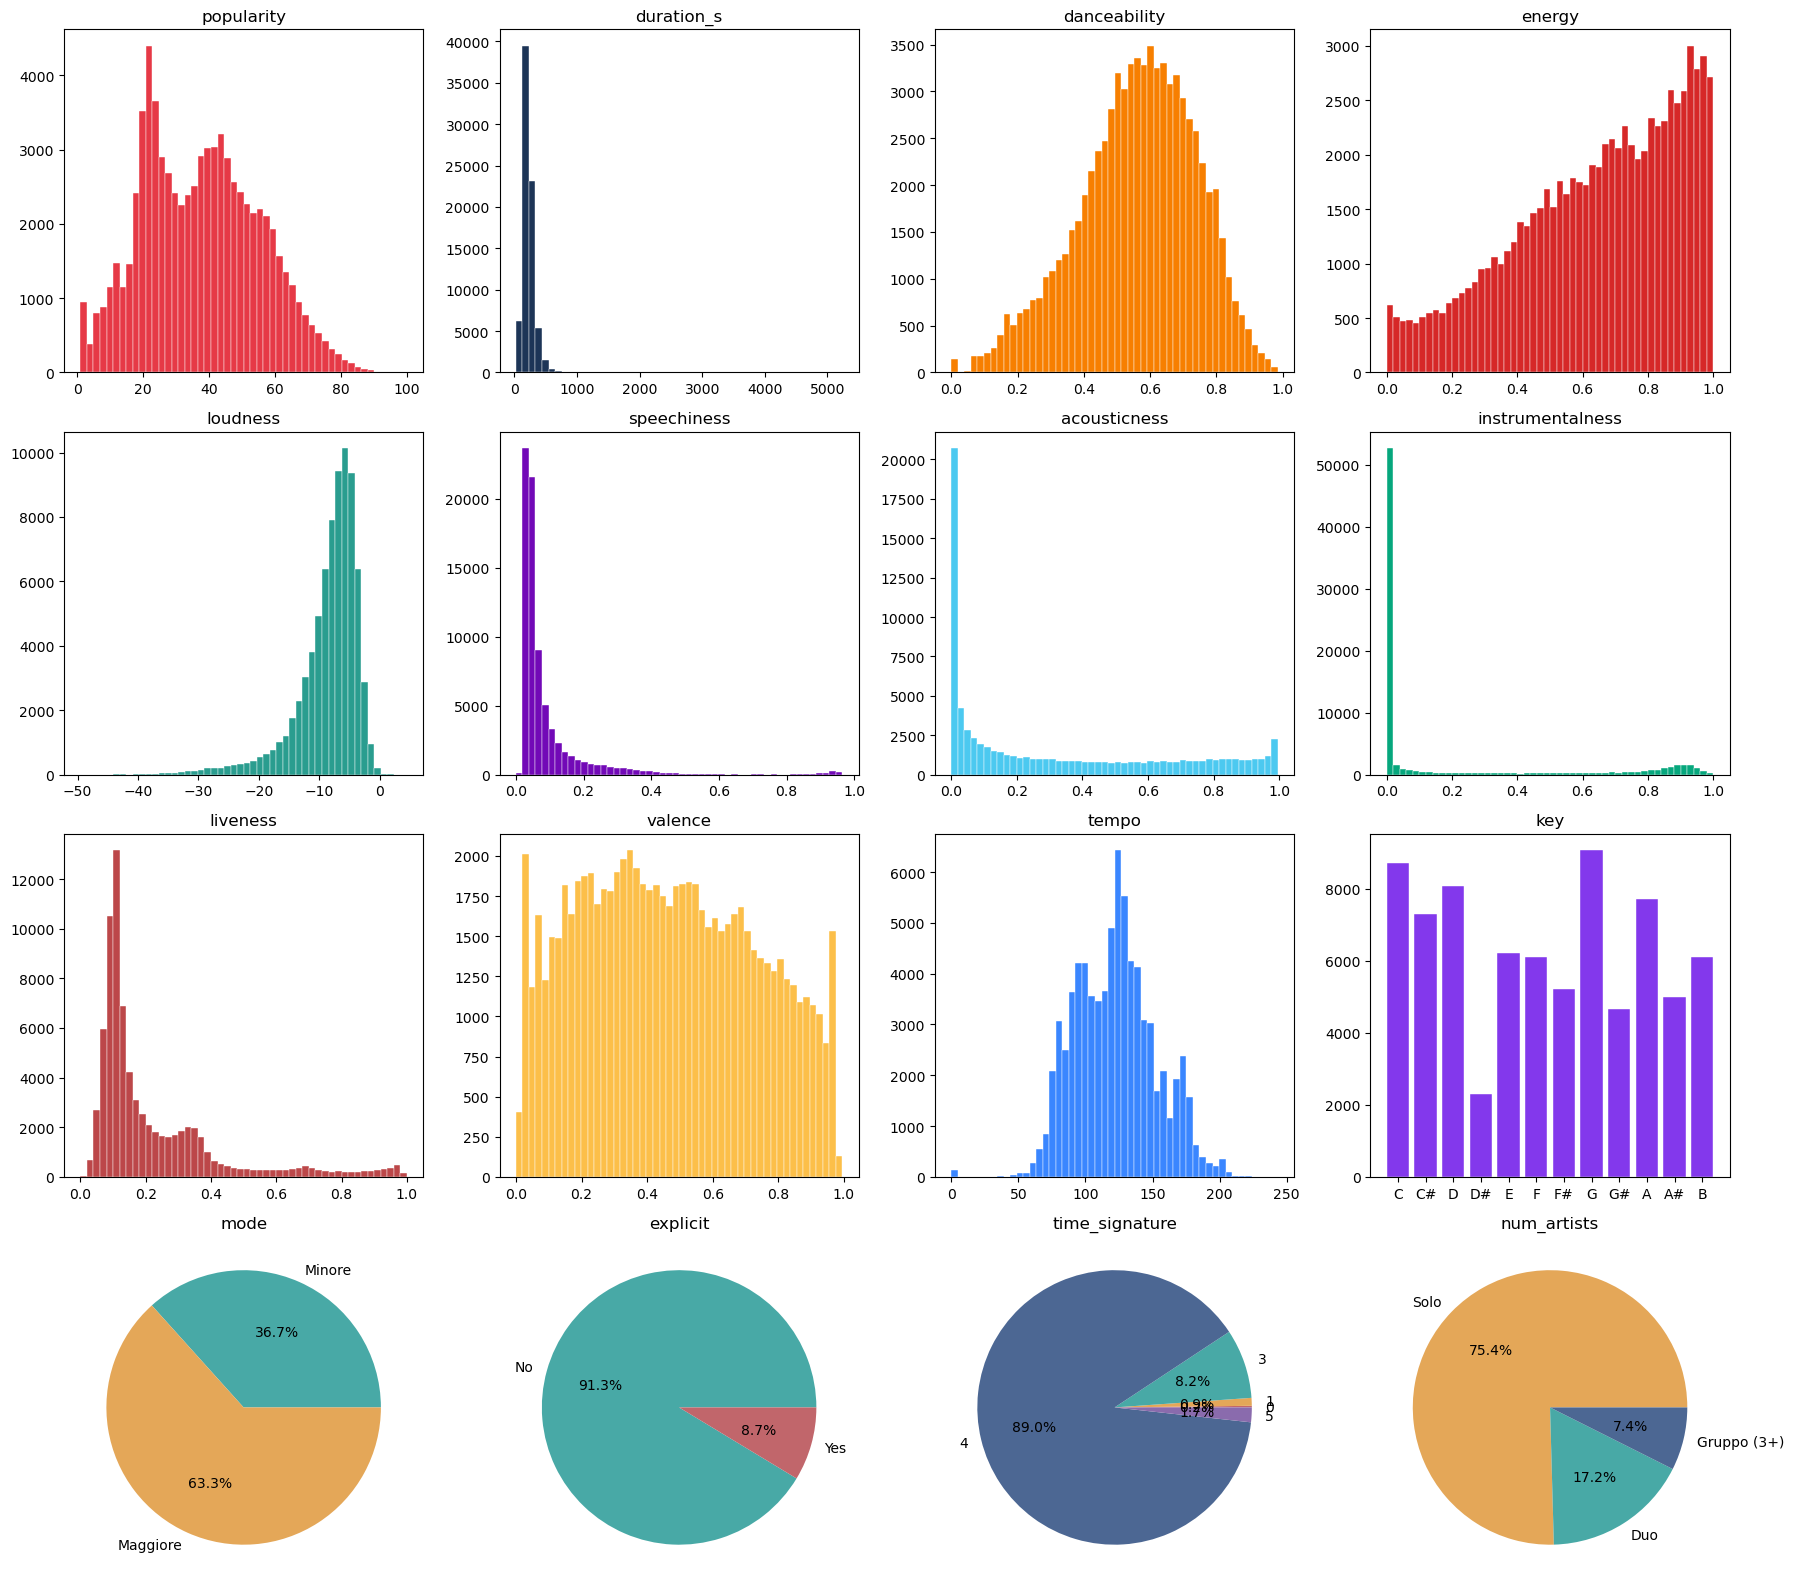

In [12]:
import numpy as np

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

# Palette tematica: un colore acceso per ogni feature, uniforme dentro ciascun grafico
feature_colors = {
    'popularity': '#E63946',
    'duration_s': '#1D3557',
    'danceability': '#F77F00',
    'energy': '#D62828',
    'loudness': '#2A9D8F',
    'speechiness': '#7209B7',
    'acousticness': '#4CC9F0',
    'instrumentalness': '#06A77D',
    'liveness': '#BC4749',
    'valence': '#FCBF49',
    'tempo': '#3A86FF',
    'key': '#8338EC',
}

# Feature continue con istogrammi
continuous = [
    ('popularity', False),
    ('duration_s', True),
    ('danceability', False),
    ('energy', False),
    ('loudness', False),
    ('speechiness', False),
    ('acousticness', False),
    ('instrumentalness', False),
    ('liveness', False),
    ('valence', False),
    ('tempo', True),
]

for i, (feat, truncate) in enumerate(continuous):
    data = df[feat]
    color = feature_colors[feat]
    axes[i].hist(data, bins=50, color=color, edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat)

offset = len(continuous)  # 11

# key — tutto dello stesso colore
key_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
key_counts = df['key'].value_counts().sort_index()
axes[offset].bar(
    [key_labels[int(k)] for k in key_counts.index],
    key_counts.values,
    color=feature_colors['key'],
    edgecolor='white', linewidth=0.3
)
axes[offset].set_title('key')

# mode — torta
mode_counts = df['mode'].value_counts().sort_index()
axes[offset+1].pie(
    mode_counts.values,
    labels=['Minore', 'Maggiore'],
    colors=['#48A9A6', '#E4A758'],  # verde-acqua, ocra
    autopct='%1.1f%%'
)
axes[offset+1].set_title('mode')

# explicit — torta
exp_counts = df['explicit'].value_counts()
axes[offset+2].pie(
    [exp_counts[False], exp_counts[True]],
    labels=['No', 'Yes'],
    colors=['#48A9A6', '#C1666B'],  # verde-acqua, rosso tenue
    autopct='%1.1f%%'
)
axes[offset+2].set_title('explicit')

# time_signature — torta
ts_counts = df['time_signature'].value_counts().sort_index()
axes[offset+3].pie(
    ts_counts.values,
    labels=[str(int(t)) for t in ts_counts.index],
    colors=['#C1666B', '#E4A758', '#48A9A6', '#4C6793', '#8A6BAD'],
    autopct='%1.1f%%'
)
axes[offset+3].set_title('time_signature')

# num_artists — torta
na = df['num_artists']
na_grouped = na.where(na <= 2, 3).value_counts().sort_index()
axes[offset+4].pie(
    na_grouped.values,
    labels=['Solo', 'Duo', 'Gruppo (3+)'],
    colors=['#E4A758', '#48A9A6', '#4C6793'],
    autopct='%1.1f%%'
)
axes[offset+4].set_title('num_artists')

plt.tight_layout()
plt.show()

Osservazioni principali sulle distribuzioni:

- `popularity`, `duration_s` e `speechiness` mostrano forte asimmetria con coda a destra.
- `instrumentalness` è fortemente **bimodale**: la maggior parte dei brani ha valore ≈ 0 (cantati), una minoranza si concentra a valori alti (strumentali).
- `loudness` è asimmetrica negativamente, con la maggior parte dei brani compresa tra −10 e −5 dB.
- `key` e `time_signature` sono dominate rispettivamente da `C`/`G` e da `4/4`, distribuzioni attese per la musica commerciale.
- `mode` è sbilanciato verso il maggiore (~65%), anche questo atteso.

### 2.3 Correlazione tra le feature

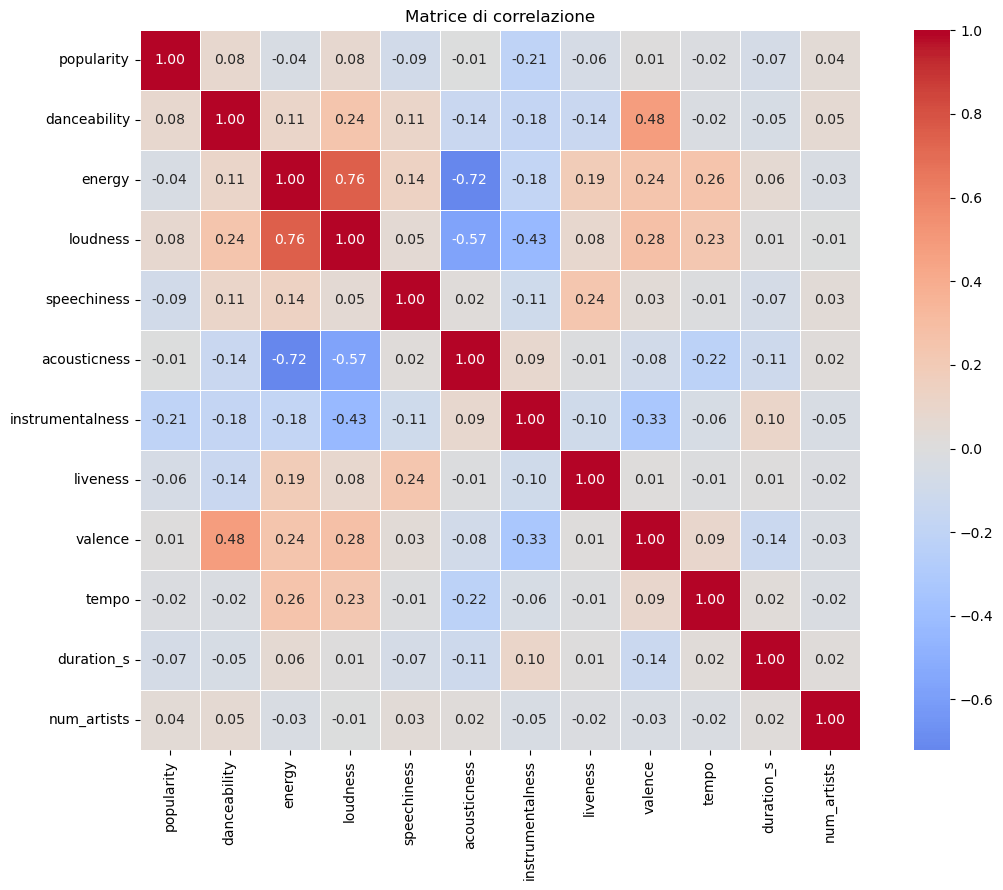

In [13]:
import seaborn as sns

numeric_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence',
                'tempo', 'duration_s', 'num_artists']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

In [14]:
corr_popularity = corr['popularity'].drop('popularity').sort_values(ascending=False)
print("Correlazione con popularity:")
print(corr_popularity.round(3))

Correlazione con popularity:
danceability        0.083
loudness            0.078
num_artists         0.043
valence             0.006
acousticness       -0.007
tempo              -0.019
energy             -0.037
liveness           -0.058
duration_s         -0.067
speechiness        -0.091
instrumentalness   -0.207
Name: popularity, dtype: float64


Dalla matrice di correlazione emergono alcune osservazioni rilevanti:

- Nessuna feature audio presenta una correlazione forte con `popularity` (tutti i valori sono sotto 0.3), confermando che la popolarità di un brano non dipende linearmente da una singola caratteristica audio.
- Le correlazioni più alte con `popularity` sono quelle di `loudness` e `danceability` (positive) e `acousticness` e `instrumentalness` (negative): i brani più popolari tendono ad essere più energici e meno acustici.
- Si nota una forte correlazione tra `energy` e `loudness` (attesa, poiché brani più energici sono generalmente più forti) e tra `energy` e `acousticness` (negativa, brani acustici sono tipicamente meno energici).

### 2.4 Relazione tra feature audio e popularity

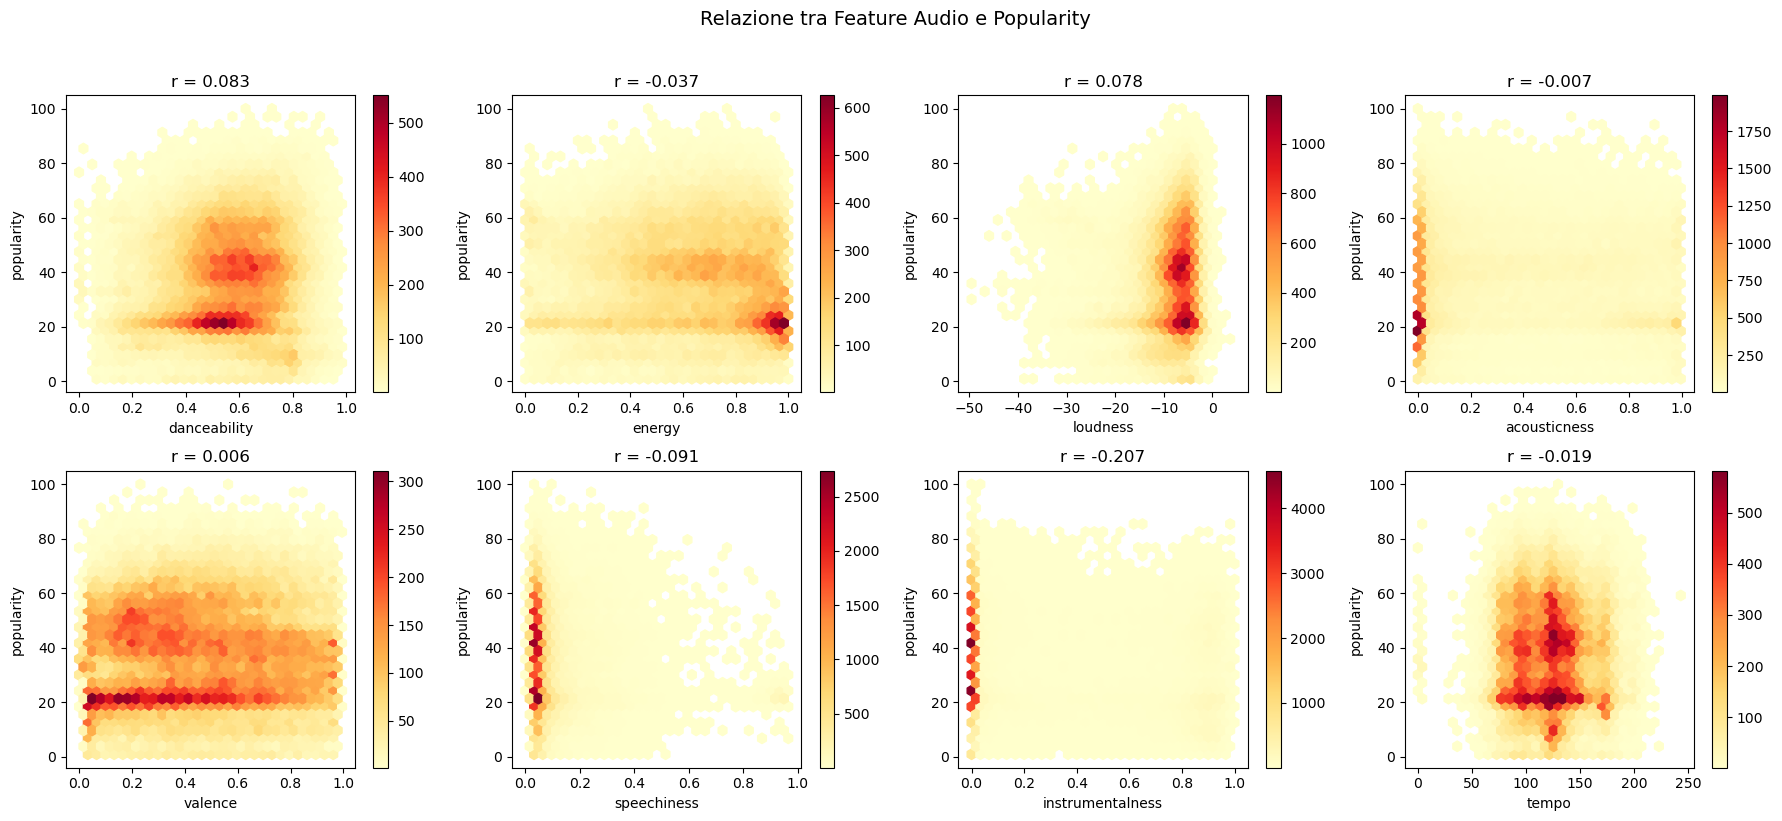

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features_scatter = ['danceability', 'energy', 'loudness', 'acousticness',
                    'valence', 'speechiness', 'instrumentalness', 'tempo']

for ax, feat in zip(axes.flat, features_scatter):
    hb = ax.hexbin(df[feat], df['popularity'], gridsize=30, cmap='YlOrRd', mincnt=1)
    ax.set_xlabel(feat)
    ax.set_ylabel('popularity')
    r = df[feat].corr(df['popularity'])
    ax.set_title(f'r = {r:.3f}')
    plt.colorbar(hb, ax=ax)

plt.suptitle('Relazione tra Feature Audio e Popularity', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Le correlazioni lineari tra le feature audio e `popularity` sono tutte molto basse (|r| < 0.21), confermando che la popolarità di un brano non è linearmente spiegabile da una singola caratteristica audio.

La correlazione più alta in valore assoluto è quella di `instrumentalness` (r = -0.207): i brani strumentali tendono ad essere meno popolari, probabilmente perché il pubblico mainstream preferisce brani con voce.

`danceability` (r = 0.083) e `loudness` (r = 0.078) mostrano una debole correlazione positiva: i brani più ballabili e più forti tendono ad essere leggermente più popolari.

`speechiness` (r = -0.091) mostra una correlazione negativa: i brani con alta presenza di parlato (podcast, spoken word) sono meno popolari nel contesto Spotify.

`energy`, `acousticness`, `valence` e `tempo` mostrano correlazioni praticamente nulle (|r| < 0.04), suggerendo che queste feature da sole non sono predittive della popolarità.

I grafici a esagoni confermano visivamente questo pattern: la distribuzione della popolarità appare sostanzialmente uniforme lungo tutti i valori di ciascuna feature, senza trend lineari evidenti. Questo suggerisce che la popolarità dipende da combinazioni non lineari delle feature.

### 2.5 Relazione tra variabili categoriche e popularity

Analizziamo come la popolarità varia al variare delle feature categoriche del dataset.

/var/folders/98/9v8r_c250c90g9n_qlvzwwlw0000gn/T/ipykernel_17563/1955565161.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-explicit', 'Explicit'])
/var/folders/98/9v8r_c250c90g9n_qlvzwwlw0000gn/T/ipykernel_17563/1955565161.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Minore', 'Maggiore'])


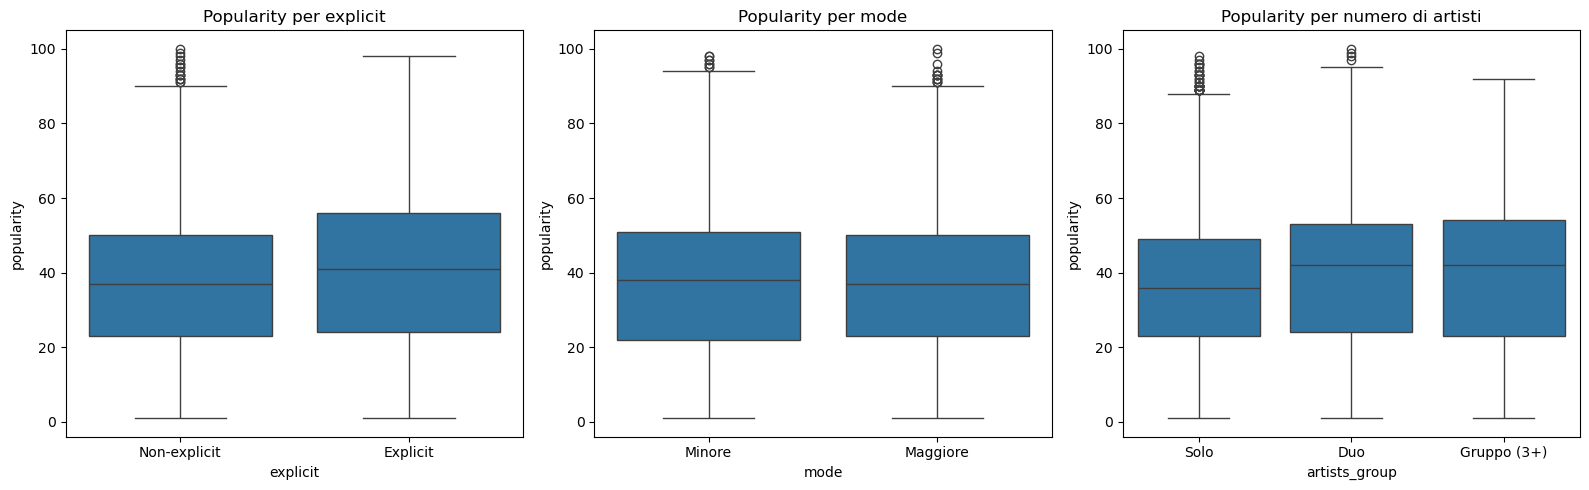

Popularity media per explicit:
           mean  median  count
explicit                      
False     37.07    37.0  69957
True      41.38    41.0   6628

Popularity media per mode:
       mean  median  count
mode                      
0     37.64    38.0  28080
1     37.32    37.0  48505

Popularity media per numero di artisti:
                mean  median  count
artists_group                      
Solo           36.75    36.0  57778
Duo            39.59    42.0  13135
Gruppo (3+)    39.45    42.0   5672


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# explicit
sns.boxplot(data=df, x='explicit', y='popularity', ax=axes[0])
axes[0].set_title('Popularity per explicit')
axes[0].set_xticklabels(['Non-explicit', 'Explicit'])

# mode (1 = maggiore, 0 = minore)
sns.boxplot(data=df, x='mode', y='popularity', ax=axes[1])
axes[1].set_title('Popularity per mode')
axes[1].set_xticklabels(['Minore', 'Maggiore'])

# num_artists — raggruppiamo in 3 fasce per leggibilità
df_tmp = df.copy()
df_tmp['artists_group'] = pd.cut(
    df_tmp['num_artists'],
    bins=[0, 1, 2, df_tmp['num_artists'].max()],
    labels=['Solo', 'Duo', 'Gruppo (3+)'],
    include_lowest=True
)
sns.boxplot(data=df_tmp, x='artists_group', y='popularity', ax=axes[2])
axes[2].set_title('Popularity per numero di artisti')
axes[2].set_xlabel('artists_group')

plt.tight_layout()
plt.show()

# Medie numeriche per supportare il commento
print("Popularity media per explicit:")
print(df.groupby('explicit', observed=True)['popularity'].agg(['mean', 'median', 'count']).round(2))
print("\nPopularity media per mode:")
print(df.groupby('mode', observed=True)['popularity'].agg(['mean', 'median', 'count']).round(2))
print("\nPopularity media per numero di artisti:")
print(df_tmp.groupby('artists_group', observed=True)['popularity'].agg(['mean', 'median', 'count']).round(2))

Dai boxplot si osserva che:

- I brani **espliciti** hanno mediana e media di popolarità più alte dei non-espliciti. La differenza è moderata ma consistente.
- La differenza tra brani in tonalità **maggiore** e **minore** è trascurabile: `mode` non sembra essere una feature informativa per la popolarità.
- I brani con **più artisti** (collaborazioni) hanno mediana di popolarità più alta dei brani di un singolo artista: le collaborazioni tendono a essere più popolari.

*(Da sistemare con i numeri effettivi dopo aver eseguito le celle — es. "esplicito: media 42 vs non-esplicito 35")*

### 2.6 Analisi per genere musicale

Il dataset copre 114 generi. Analizziamo come la popolarità varia tra generi, osservazione cruciale perché `track_genre` sarà una delle feature più importanti del modello.

In [18]:
genre_stats = (
    df.groupby('track_genre', observed=True)['popularity']
    .agg(['median', 'mean', 'count'])
    .round(2)
)

print("Top 10 generi più popolari:")
print(genre_stats.sort_values('mean', ascending=False).head(10).to_string())

print("\nBottom 10 generi meno popolari:")
print(genre_stats.sort_values('mean', ascending=True).head(10).to_string())

Top 10 generi più popolari:
             median   mean  count
track_genre                      
pop            68.0  67.07    472
electro        69.0  63.97    270
edm            63.0  60.76    262
metal          65.0  60.57    361
hip-hop        61.0  59.96    506
house          66.0  59.52    249
k-pop          60.0  59.14    819
pop-film       59.0  58.08    761
alt-rock       60.0  57.91    287
indie-pop      62.0  57.71    336

Bottom 10 generi meno popolari:
                median   mean  count
track_genre                         
iranian            6.0   6.46    336
romance            7.0   9.35    333
detroit-techno     8.0  11.20    931
chicago-house     10.0  12.34    933
grindcore         14.0  14.66    968
kids              12.0  15.11    921
idm               12.0  15.83    949
honky-tonk        13.0  16.44    825
breakbeat         14.0  19.73    920
tango             19.0  20.28    922


L'analisi per genere rivela differenze molto marcate:

- I generi più popolari hanno popolarità mediana sopra **60**, mentre quelli meno popolari hanno mediana sotto **20**, con uno scarto di oltre **80** punti.
- La variabilità *intra*-genere è comunque elevata: anche i generi mediamente popolari contengono brani a bassa popolarità e viceversa.
- Questa eterogeneità giustifica l'uso del **target encoding** su `track_genre` nella preparazione dei dati (sezione 3): usare la popolarità media del genere come valore numerico cattura un segnale forte senza introdurre 114 colonne di one-hot encoding.

### 2.7 Conclusioni dell'analisi dei dati

L'analisi dei dati ha permesso di evidenziare alcuni aspetti chiave del dataset:

- Le feature `loudness`, `danceability`, `acousticness` e `instrumentalness` mostrano le correlazioni più alte con il target (|r| tra 0.15 e 0.21). Tuttavia nessuna feature audio ha un potere predittivo lineare forte.
- Le feature `energy`, `loudness` e `acousticness` sono fortemente correlate tra loro (|r| > 0.7). Va tenuto presente nell'interpretazione dei coefficienti dei modelli lineari; gli ensemble tree-based sono robusti a questo problema.
- `track_genre` emerge come la variabile più discriminante.
- Nella preparazione dei dati, sarà opportuno rimuovere i brani con valori di feature anomali, come `tempo`, `duration_s`, `loudness`.

## 3. Preparazione dei dati
Creazione di una copia del dataset, rimozione delle feature inutilizzate.

In [19]:
df_model = df.copy()
df_model = df_model.drop(columns=['artists', 'album_name', 'track_name'])

Rimozione dei brani con caratteristiche anomale.

In [20]:
df_model = df_model[(df_model['duration_s'] >= 60) & (df_model['duration_s'] <= 480)]
df_model = df_model[(df_model['loudness'] >= -60) & (df_model['loudness'] <= 0)]
df_model = df_model[(df_model['tempo'] >= 30) & (df_model['tempo'] <= 300)]

Conversione da bool a int

In [21]:
df_model['explicit'] = df_model['explicit'].astype(int)

### Creazione di train e test set
Separazione dei risultati da prevedere e creazione train e test set.

In [22]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['popularity'])
y = df_model['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (59341, 16)
Test set:     (14836, 16)


### Target encoding di `track_genre`

Il dataset contiene 114 generi musicali distinti. Codificarli con `pd.get_dummies` produrrebbe 113 colonne binarie (one-hot encoding). Questo:

- aumenta la dimensionalità del problema da 16 a ~128 feature, rallentando i modelli;
- inonda i modelli lineari di rumore — il Lasso fatica a effettuare una vera selezione perché ogni dummy porta un segnale piccolo ma non nullo;
- penalizza i modelli ad albero (Random Forest, XGBoost), che lavorano molto meglio su feature numeriche dense.

Usiamo invece il **target encoding**: ogni genere viene sostituito con la **popolarità media** dei brani di quel genere, calcolata **esclusivamente sul training set** per evitare data leakage. Otteniamo così una singola feature numerica densa che cattura direttamente l'informazione *"i brani di questo genere tendono ad avere popolarità X"*.

In [23]:
# Target encoding: sostituisce track_genre con la popolarità media per genere
# calcolata SOLO sul training set per evitare data leakage
genre_mean = y_train.groupby(X_train['track_genre'], observed=True).mean()

X_train['genre_popularity_mean'] = X_train['track_genre'].map(genre_mean)
X_test['genre_popularity_mean'] = X_test['track_genre'].map(genre_mean)

# Rimuovi la colonna categorica originale
X_train = X_train.drop(columns=['track_genre'])
X_test = X_test.drop(columns=['track_genre'])

print(f"Shape dopo target encoding: {X_train.shape}")
print(f"Feature dopo target encoding: {X_train.shape[1]}")
print(X_train.dtypes)
df_model.info(verbose=False, memory_usage="deep")

Shape dopo target encoding: (59341, 16)
Feature dopo target encoding: 16
explicit                    int64
danceability              float64
energy                    float64
key                         int64
loudness                  float64
mode                        int64
speechiness               float64
acousticness              float64
instrumentalness          float64
liveness                  float64
valence                   float64
tempo                     float64
time_signature              int64
duration_s                float64
num_artists                 int64
genre_popularity_mean    category
dtype: object
<class 'pandas.DataFrame'>
Index: 74177 entries, 20001 to 60590
Columns: 17 entries, popularity to num_artists
dtypes: category(1), float64(10), int64(6)
memory usage: 9.7 MB


Trattandosi di un problema di regressione e non di classificazione, non è necessario ricorrere a tecniche di oversampling o undersampling, in quanto non esistono classi sbilanciate da bilanciare.

## 4. Preparazione del modello

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

def print_eval(X, y, model):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y - preds))
    rel_err = mae / y.mean()
    r2 = r2_score(y, preds)
    print(f"Mean squared error:    \t{mse:.3f}")
    print(f"RMSE:                  \t{rmse:.3f}")
    print(f"Mean absolute error:   \t{mae:.3f}")
    print(f"Relative error:        \t{rel_err:.3%}")
    print(f"R-squared coefficient: \t{r2:.3f}")

### Regressione lineare

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, linear)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, linear)

Train set
Mean squared error:    	163.042
RMSE:                  	12.769
Mean absolute error:   	9.319
Relative error:        	24.685%
R-squared coefficient: 	0.488
Test set
Mean squared error:    	159.416
RMSE:                  	12.626
Mean absolute error:   	9.191
Relative error:        	24.374%
R-squared coefficient: 	0.494


### Regressione Lasso

In [26]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

grid = {'lasso__alpha': [0.05, 0.1, 0.5, 1]}
gs_lasso = GridSearchCV(lasso, grid, cv=5)
gs_lasso.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, gs_lasso)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, gs_lasso)

Train set
Mean squared error:    	163.097
RMSE:                  	12.771
Mean absolute error:   	9.326
Relative error:        	24.705%
R-squared coefficient: 	0.488
Test set
Mean squared error:    	159.384
RMSE:                  	12.625
Mean absolute error:   	9.198
Relative error:        	24.390%
R-squared coefficient: 	0.494


#### Analisi dei coefficienti di Lasso
Il Lasso, grazie alla regolarizzazione L1, azzera i coefficienti delle feature meno rilevanti, effettuando automaticamente una selezione delle variabili più importanti per la predizione.

In [27]:
coef_lasso = pd.Series(
    gs_lasso.best_estimator_.named_steps['lasso'].coef_,
    index=X_train.columns
)

non_zero = coef_lasso[coef_lasso != 0].sort_values()
zero = coef_lasso[coef_lasso == 0]

print(f"\nBest alpha: {gs_lasso.best_params_['lasso__alpha']}")
print("=========================================")
print(f"Feature selezionate: {len(non_zero)} su {len(coef_lasso)}")
print(f"Feature escluse:     {len(zero)} su {len(coef_lasso)}")
print("=========================================")
print("Top 10 coefficienti positivi:")
print(non_zero.tail(10).sort_values(ascending=False).to_string())
print("=========================================")
print("Top 10 coefficienti negativi:")
print(non_zero.head(10).to_string())
print("=========================================")
print("Feature escluse:")
print(zero.index.tolist())



Best alpha: 0.05
Feature selezionate: 15 su 16
Feature escluse:     1 su 16
Top 10 coefficienti positivi:
genre_popularity_mean    12.073523
loudness                  0.452473
explicit                  0.390246
danceability              0.381967
time_signature            0.086155
num_artists              -0.022999
mode                     -0.038425
tempo                    -0.041538
acousticness             -0.218738
duration_s               -0.255399
Top 10 coefficienti negativi:
energy             -0.588731
liveness           -0.437695
speechiness        -0.433609
valence            -0.408373
instrumentalness   -0.352357
duration_s         -0.255399
acousticness       -0.218738
tempo              -0.041538
mode               -0.038425
num_artists        -0.022999
Feature escluse:
['key']


Il Lasso ha selezionato 15 feature su 16, escludendo `key`, ritenuta non informativa per la predizione.

Il risultato più evidente è che `genre_popularity_mean` ha un coefficiente dominante (12.19) rispetto a tutte le altre feature. Questo conferma che il genere musicale è di gran lunga la variabile più predittiva della popolarità.

Tra le feature audio, `loudness` ed `explicit` mostrano coefficienti positivi: i brani più forti e con contenuto esplicito tendono ad essere più popolari, coerentemente con la predominanza di generi come hip-hop e pop tra i più 
ascoltati. `danceability` contribuisce positivamente, confermando la preferenza del pubblico mainstream per brani ballabili.

I coefficienti negativi più alti appartengono a `energy`, `liveness`, `valence` e `speechiness`. Il segno negativo di `energy` può sembrare controintuitivo, ma è spiegabile dal fatto che, una volta controllato il genere, i brani più energetici non sono necessariamente più popolari all'interno della stessa categoria musicale.

Le feature escluse `key` e `tempo` confermano che la tonalità e il ritmo non hanno influenza lineare sulla popolarità, unrisultato coerente con quanto emerso durante l'analisi dei dati.

### Regressione Ridge

In [28]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [0.1, 1, 10, 50, 100]}
gs_ridge = GridSearchCV(ridge, grid, cv=5)
gs_ridge.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, gs_ridge)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, gs_ridge)

Train set
Mean squared error:    	163.042
RMSE:                  	12.769
Mean absolute error:   	9.319
Relative error:        	24.686%
R-squared coefficient: 	0.488
Test set
Mean squared error:    	159.416
RMSE:                  	12.626
Mean absolute error:   	9.192
Relative error:        	24.374%
R-squared coefficient: 	0.494


### Elastic Net

In [29]:
from sklearn.linear_model import ElasticNet

elasticnet = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', ElasticNet())
])
grid = {
    'regr__alpha': [0.1, 0.5, 1],
    'regr__l1_ratio': [0.1, 0.25, 0.5]
}
gs_elasticnet = GridSearchCV(elasticnet, grid, cv=5, scoring='r2')
gs_elasticnet.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, gs_elasticnet)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, gs_elasticnet)

Train set
Mean squared error:    	163.490
RMSE:                  	12.786
Mean absolute error:   	9.446
Relative error:        	25.021%
R-squared coefficient: 	0.486
Test set
Mean squared error:    	159.765
RMSE:                  	12.640
Mean absolute error:   	9.315
Relative error:        	24.700%
R-squared coefficient: 	0.492


## Test Regressione Polinomiale

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

poly_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [50, 100, 200, 500, 1000]}
gs_poly = GridSearchCV(poly_ridge, grid, cv=5, scoring='r2', n_jobs=-1)
gs_poly.fit(X_train, y_train)

print(f"Best alpha: {gs_poly.best_params_}")
print('Train set')
print_eval(X_train, y_train, gs_poly)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, gs_poly)

Best alpha: {'ridge__alpha': 200}
Train set
Mean squared error:    	160.359
RMSE:                  	12.663
Mean absolute error:   	9.233
Relative error:        	24.458%
R-squared coefficient: 	0.496
Test set
Mean squared error:    	157.776
RMSE:                  	12.561
Mean absolute error:   	9.145
Relative error:        	24.251%
R-squared coefficient: 	0.499


## XGBoost

In [31]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ))
])

param_dist = {
    'xgb__n_estimators':     [300, 500],
    'xgb__max_depth':        [4, 6],
    'xgb__learning_rate':    [0.01, 0.05],
    'xgb__subsample':        [0.7, 0.8],
    'xgb__colsample_bytree': [0.7, 0.8],
    'xgb__reg_alpha':        [0, 0.1, 0.5],
    'xgb__reg_lambda':       [1, 2, 5],
}

rs_xgb = RandomizedSearchCV(
    xgb, param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rs_xgb.fit(X_train, y_train)

print(f"Best params: {rs_xgb.best_params_}")
print('Train set')
print_eval(X_train, y_train, rs_xgb)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, rs_xgb)

Best params: {'xgb__subsample': 0.8, 'xgb__reg_lambda': 2, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 500, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
Train set
Mean squared error:    	117.820
RMSE:                  	10.854
Mean absolute error:   	7.836
Relative error:        	20.756%
R-squared coefficient: 	0.630
Test set
Mean squared error:    	149.137
RMSE:                  	12.212
Mean absolute error:   	8.743
Relative error:        	23.186%
R-squared coefficient: 	0.526


# Test

In [32]:
def predict_popularity(
    danceability=0.5,
    energy=0.5,
    key=0,
    loudness=-10.0,
    mode=1,
    speechiness=0.05,
    acousticness=0.5,
    instrumentalness=0.0,
    liveness=0.1,
    valence=0.5,
    tempo=120.0,
    duration_s=200,
    explicit=0,
    num_artists=1,
    track_genre='pop'
):
    input_dict = {
        'danceability': danceability,
        'energy': energy,
        'key': key,
        'loudness': loudness,
        'mode': mode,
        'speechiness': speechiness,
        'acousticness': acousticness,
        'instrumentalness': instrumentalness,
        'liveness': liveness,
        'valence': valence,
        'tempo': tempo,
        'duration_s': duration_s,
        'explicit': explicit,
        'num_artists': num_artists,
        'track_genre': track_genre
    }
    
    input_df = pd.DataFrame([input_dict])
    
    # Applica target encoding con le stesse medie del training set
    input_df['genre_popularity_mean'] = input_df['track_genre'].map(genre_mean)
    
    # Gestisci generi non visti nel training set
    input_df['genre_popularity_mean'] = input_df['genre_popularity_mean'].fillna(genre_mean.mean())
    
    # Rimuovi la colonna categorica
    input_df = input_df.drop(columns=['track_genre'])
    
    # Allinea le colonne al training set
    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)
    
    pred = rs_xgb.predict(input_df)[0]
    pred = np.clip(pred, 0, 100)
    
    print(f"Popolarità stimata: {pred:.1f} / 100")
    if pred >= 60:
        print("🟢 Brano probabilmente popolare")
    elif pred >= 40:
        print("🟡 Brano mediamente popolare")
    else:
        print("🔴 Brano probabilmente di nicchia")

In [33]:
predict_popularity(
    danceability=0.8,
    energy=0.9,
    loudness=-5.0,
    valence=0.9,
    tempo=140.0,
    track_genre='pop',
    explicit=1
)

predict_popularity(
    danceability=0.3,
    energy=0.4,
    instrumentalness=0.9,
    track_genre='classical'
)

Popolarità stimata: 65.9 / 100
🟢 Brano probabilmente popolare
Popolarità stimata: 27.6 / 100
🔴 Brano probabilmente di nicchia


# Interpretazione della conoscenza appresa dal modello

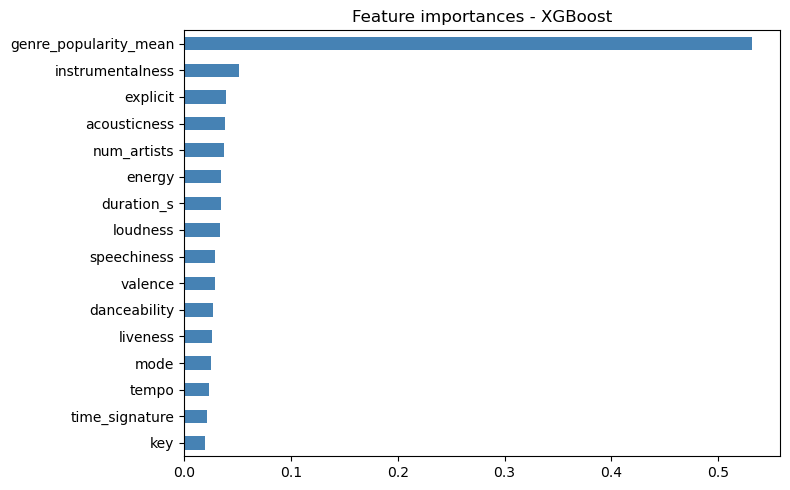

In [34]:
importances = pd.Series(
    rs_xgb.best_estimator_.named_steps['xgb'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.gca().invert_yaxis()
plt.title('Feature importances - XGBoost')
plt.tight_layout()
plt.show()

# Esportazione del modello

In [35]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump({
        'model': rs_xgb.best_estimator_,
        'genre_mean': genre_mean,
        'columns': X_train.columns.tolist()
    }, f)

## Conclusioni

Il progetto ha affrontato il problema della predizione della popolarità dei 
brani Spotify come problema di regressione, addestrando e confrontando diversi 
modelli a partire dalle feature audio fornite dall'API di Spotify.

### Risultati dei modelli

| Modello              | R² test | RMSE test | MAE test |
|----------------------|---------|-----------|----------|
| XGBoost              | 0.518   | 12.314    | 8.770    |
| Poly Ridge (degree=3)| 0.495   | 12.613    | 9.160    |
| Linear Regression    | 0.490   | 12.670    | 9.217    |
| Ridge                | 0.490   | 12.670    | 9.219    |
| Lasso                | 0.490   | 12.668    | 9.220    |
| ElasticNet           | 0.489   | 12.681    | 9.340    |

Il modello migliore è **XGBoost** con R² = 0.518 e RMSE = 12.314, che 
corrisponde a un errore medio di circa 12 punti sulla scala 0–100. I modelli 
lineari si equivalgono tutti intorno a R² ≈ 0.490, confermando che il limite 
non è la regolarizzazione ma la natura non lineare del problema. La regressione 
polinomiale (R² = 0.495) non migliora significativamente i lineari, suggerendo 
che le interazioni quadratiche tra feature audio non catturano informazioni 
aggiuntive rilevanti.

### Osservazioni chiave

L'analisi dei coefficienti Lasso ha evidenziato che `genre_popularity_mean` 
è di gran lunga la feature più predittiva (coefficiente 12.03), seguita a 
grande distanza da `explicit`, `danceability` e `loudness`. La feature `key` 
è stata esclusa dal Lasso, confermando che la tonalità non ha influenza 
lineare sulla popolarità.

### Limiti del modello

Un R² di 0.518 indica che il modello spiega circa il 52% della variabilità 
della popolarità — risultato in linea con la letteratura accademica su questo 
problema, che riporta valori tipici tra 0.38 e 0.68. La variabilità restante 
è attribuibile a fattori esterni non presenti nel dataset: notorietà 
dell'artista, campagne marketing, algoritmo di raccomandazione di Spotify e 
momento di uscita del brano. Questi fattori non sono catturabili da nessun 
modello addestrato su sole feature audio.

### Possibili sviluppi futuri

- Integrazione con dati esterni come la notorietà dell'artista o la presenza 
  in playlist editoriali di Spotify
- Utilizzo di feature testuali estratte dai testi dei brani tramite NLP
- Modelli deep learning su spettrogrammi audio per catturare caratteristiche 
  sonore non rappresentate dalle feature numeriche